# Otimização Multivariável Sem Restrições — Gradiente e Newton

Tradução em Python dos scripts MATLAB da pasta `Opt_MD` (`Main_MD.m`, `MD_Gradiente.m`,
`MD_Newton.m`, `DivisaoAurea_busca.m`, `f.m`, `dfdx.m`, `df2dx2.m`, `graf.m`).

Minimização, sem restrições, da função quadrática de teste
$f(x_1,x_2) = x_1^2 + 2x_2^2 - 2x_1 - x_2$ por dois métodos multivariáveis, ambos usando
**busca em linha pelo método da Divisão Áurea** para o passo $\lambda$:
- **Método do Gradiente (máximo descenso)** — direção $d_k=-\nabla f(x_k)$;
- **Método de Newton** — direção $d_k=-H^{-1}\nabla f(x_k)$, com Hessiana $H$ constante
  para esta função quadrática (convergência em uma única iteração).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (habilita projection='3d')

## Função objetivo, gradiente e Hessiana (`f.m`, `dfdx.m`, `df2dx2.m`)

In [3]:
def f(x):
    """Função objetivo multidimensional."""
    return x[0] ** 2 + 2 * x[1] ** 2 - 2 * x[0] - x[1]


def dfdx(x):
    """Gradiente da função multidimensional."""
    return np.array([2 * x[0] - 2, 4 * x[1] - 1])


def df2dx2(x):
    """Hessiana da função multidimensional."""
    return np.array([[2.0, 0.0], [0.0, 4.0]])

## Busca em linha e métodos multivariáveis (`DivisaoAurea_busca.m`, `MD_Gradiente.m`,
`MD_Newton.m`)

`divisao_aurea_busca` encontra o passo $\lambda \in [0,10]$ que minimiza
$f(x+\lambda d)$ ao longo da direção de busca $d$. `md_gradiente` e `md_newton` reproduzem
os laços originais, armazenando todos os pontos visitados $x_k$ para o gráfico de
convergência.

In [4]:
def divisao_aurea_busca(I, x, d):
    """Busca em linha (1D) pelo método da Divisão Áurea. Precisa de f."""
    eps = 1e-5
    ak, bk = I
    Lk = bk - ak

    lam = [(ak + bk) / 2]
    k = 0

    while Lk > 2 * eps:
        vk = ak + 0.382 * Lk
        wk = ak + 0.618 * Lk

        if f(x + vk * d) < f(x + wk * d):
            bk = wk
        else:
            ak = vk
        Lk = bk - ak

        lam.append((ak + bk) / 2)
        k += 1
        if k == 99:
            print('Número máximo de iterações na busca unidimensional!')
            break

    return lam[-1]


def md_gradiente(Ci):
    """Método do gradiente (máximo descenso). Precisa de dfdx."""
    epsilon = 1e-4
    Ci = np.asarray(Ci, dtype=float)

    gk = dfdx(Ci)
    x = [Ci.copy()]
    k = 0

    while np.linalg.norm(gk) > epsilon:
        k += 1
        if k > 300:
            print('Limite máximo de iterações atingido. Solução não encontrada!')
            break

        dk = -gk
        if dk @ gk > 0:
            print('Direção de subida tomada, ao invés da de descida!')
            break

        lam = divisao_aurea_busca([0, 10], x[k - 1], dk)
        x.append(x[k - 1] + lam * dk)
        gk = dfdx(x[k])

    return np.array(x).T, k - 1


def md_newton(Ci):
    """Método de Newton. Precisa de dfdx e df2dx2."""
    epsilon = 1e-4
    Ci = np.asarray(Ci, dtype=float)

    gk = dfdx(Ci)
    hessi = df2dx2(Ci)
    x = [Ci.copy()]
    k = 0

    while np.linalg.norm(gk) > epsilon:
        k += 1
        if k > 300:
            print('Limite máximo de iterações atingido. Solução não encontrada!')
            break

        dk = -np.linalg.inv(hessi) @ gk
        if dk @ gk > 0:
            print('Direção de subida tomada, ao invés da de descida!')
            break

        lam = divisao_aurea_busca([0, 10], x[k - 1], dk)
        x.append(x[k - 1] + lam * dk)
        gk = dfdx(x[k])
        hessi = df2dx2(x[k])

    return np.array(x).T, k - 1


def graf(x):
    """Superfície 3D de f e trajetória da otimização sobre as curvas de nível."""
    a = max(np.ptp(x[0, :]), np.ptp(x[1, :])) / 5
    if a == 0:
        a = 1

    tx = np.linspace(x[0, :].min() - a, x[0, :].max() + a, 51)
    ty = np.linspace(x[1, :].min() - a, x[1, :].max() + a, 51)
    Tx, Ty = np.meshgrid(tx, ty)
    Z = Tx ** 2 + 2 * Ty ** 2 - 2 * Tx - Ty

    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(Tx, Ty, Z, cmap='viridis')
    fig.colorbar(surf)
    plt.show()

    plt.figure(figsize=(6, 5))
    cs = plt.contour(Tx, Ty, Z, 20)
    plt.colorbar(cs)
    plt.title('Busca da solução')
    plt.plot(x[0, :], x[1, :], 'k*')
    plt.plot(x[0, :], x[1, :], 'k-')
    plt.show()

## Execução (`Main_MD.m`)

Chute inicial $C_i=[0,0]^T$. O script original executa um único método por vez
(comentando o outro); aqui os dois são executados e seus gráficos de convergência gerados.

--- Método do Gradiente ---
Ponto ótimo
x* = [0.9999699  0.24999248]
Valor mínimo de f(x)
fmin = -1.125000
Iterações: 7



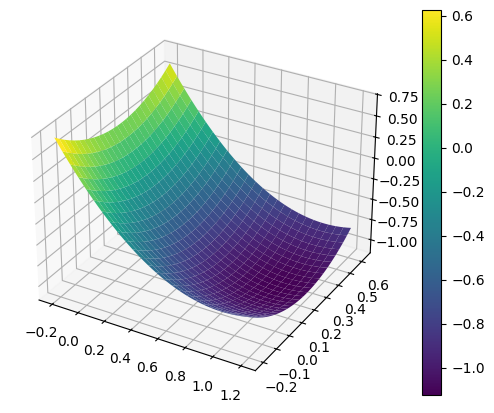

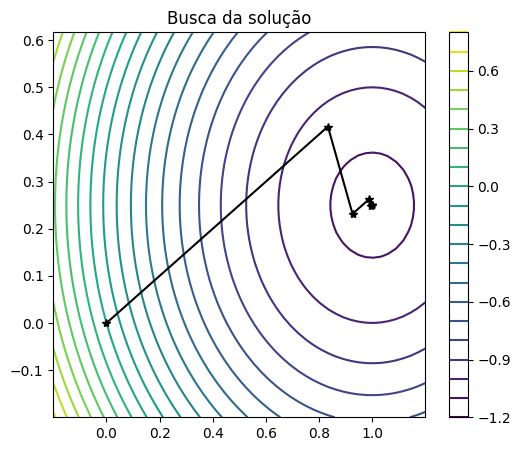

--- Método de Newton ---
Ponto ótimo
x* = [1.00000021 0.25000005]
Valor mínimo de f(x)
fmin = -1.125000
Iterações: 0



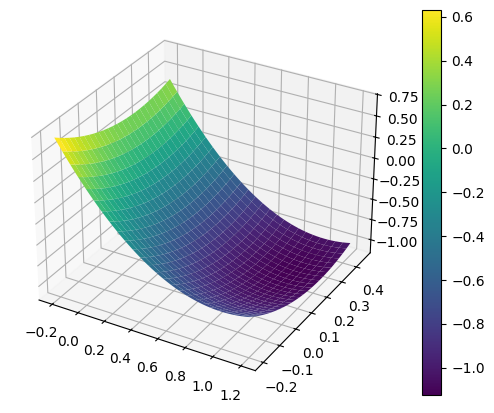

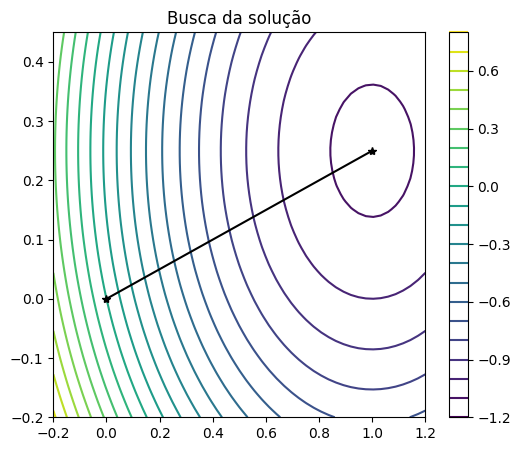

In [5]:
Ci = [0, 0]

x_grad, k_grad = md_gradiente(Ci)
print('--- Método do Gradiente ---')
print(f'Ponto ótimo\nx* = {x_grad[:, -1]}')
print(f'Valor mínimo de f(x)\nfmin = {f(x_grad[:, -1]):.6f}')
print(f'Iterações: {k_grad}\n')
graf(x_grad)

x_newt, k_newt = md_newton(Ci)
print('--- Método de Newton ---')
print(f'Ponto ótimo\nx* = {x_newt[:, -1]}')
print(f'Valor mínimo de f(x)\nfmin = {f(x_newt[:, -1]):.6f}')
print(f'Iterações: {k_newt}\n')
graf(x_newt)